# Probabilistic Power System Planning

## Course Information

- **Course**: SET3065 – Intelligent Electrical Power Grid  
- **University**: Delft University of Technology (TU Delft)  
- **Instructor**: Prof. Dr. Pedro P. Vergara  
- **Teaching Assistant**: Weijie Xia  


# Introduction

In recent years, **probabilistic power system planning** has garnered increasing interest, particularly as the power grid grows in complexity due to factors such as distributed generation, renewable integration, and evolving load patterns. The need for **stochastic modeling** of loads and generation sources is evident: static, deterministic models often fail to capture the highly variable and uncertain nature of modern power systems.

To address these challenges, **Generative AI** methods have emerged as promising tools. By leveraging statistical models—especially **Gaussian Mixture Models (GMMs)**—and **high-dimensional Gaussian distributions**, system planners can more effectively represent the range of possible load scenarios and the probabilistic nature of power flow outcomes. This approach not only provides insights into normal operating conditions but also illuminates potential **risk areas** and **voltage stability** concerns that might arise under less common, high-stress conditions.

In this assignment, we will use the **IEEE 33-bus system** (or a similar radial distribution network) as our case study. The workflow includes:

1. Generating synthetic bus loads from **high-dimensional Gaussian distributions**, illustrating how each bus's active power consumption can be drawn from a correlated random model.
2. **Fitting Gaussian Mixture Models (GMMs)** to **total daily consumption** in order to better capture the multimodal nature of load demand that might occur over a 24-hour period.
3. Conducting **probabilistic power flow analyses** by sampling from these GMMs, thereby evaluating voltage distributions across the network under various load scenarios.
4. Investigating the impact of **increasing total daily consumption** on the overall voltage stability of the system, highlighting how load growth can be examined within a probabilistic framework.

By the end of this assignment, you will have a practical demonstration of how **Generative AI** tools, in conjunction with software like **pandapower**, can inform planning and operational decisions in modern power systems.


In [1]:
!pip install pandapower
!pip install power-grid-model
!pip install power_grid_model_io

In [2]:
##########################
# IMPORTS AND SETUP
##########################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandapower as pp
import pandapower.networks as pn
import pandapower.converter as pc
from power_grid_model_io.converters import PandaPowerConverter

from sklearn.mixture import GaussianMixture
from power_grid_model import CalculationType
from power_grid_model import PowerGridModel

##########################
# CREATE THE IEEE 33-BUS NETWORK IN PANDAPOWER
##########################

# Directly load the built-in 33-bus network
net = pn.case33bw()

# Set realistic thermal current limit for all lines (200 A typical MV cable)
net.line['max_i_ka'] = 0.2

print("pandapower total P load [MW]:", net.load.p_mw.sum())
print("pandapower total Q load [MVAr]:", net.load.q_mvar.sum())


pp.runpp(net)
net.res_bus

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


pandapower total P load [MW]: 3.715
pandapower total Q load [MVAr]: 2.3


,vm_pu,va_degree,p_mw,q_mvar
0,1.000000,0.000000,-3.917677,-2.435141
1,0.997032,0.014481,0.100000,0.060000
2,0.982938,0.096042,0.090000,0.040000
3,0.975456,0.161651,0.120000,0.080000
4,0.968059,0.228285,0.060000,0.030000
5,0.949658,0.133853,0.060000,0.020000
6,0.946173,-0.096474,0.200000,0.100000
7,0.941328,-0.060403,0.200000,0.100000
8,0.935059,-0.133485,0.060000,0.020000
9,0.929244,-0.196014,0.060000,0.020000


In [3]:
################################################
# In this course, we aim to study PowerGridModel, so we can copy the parameter in pandapower to PowerGridModel
################################################

# Create a converter
converter = PandaPowerConverter()
input_data_pgm, extra_info = converter.load_input_data(net)
print("pandapower total P load [MW]:", net.load.p_mw.sum())
print("pandapower total Q load [MVAr]:", net.load.q_mvar.sum())

p = input_data_pgm["sym_load"]["p_specified"]
q = input_data_pgm["sym_load"]["q_specified"]
print("PGM p_specified sum:", float(p.sum()), "min/max:", float(p.min()), float(p.max()))
print("PGM q_specified sum:", float(q.sum()), "min/max:", float(q.min()), float(q.max()))
print("sym_load count:", len(input_data_pgm["sym_load"]), "node count:", len(input_data_pgm["node"]))
input_data_pgm['line']['tan1'] = 0.0 # Assign 0 to tan1

# Create a network of power grid model
pgm = PowerGridModel(input_data=input_data_pgm, system_frequency=50.0)

# Run power flow
output_pgm = pgm.calculate_power_flow()
pd.DataFrame(output_pgm['node'])

pandapower total P load [MW]: 3.715
pandapower total Q load [MVAr]: 2.3
PGM p_specified sum: 3715000.0 min/max: 0.0 420000.0
PGM q_specified sum: 2300000.0 min/max: 0.0 600000.0
sym_load count: 96 node count: 33


,id,energized,u_pu,u,u_angle,p,q
0,0,1,0.999719,12656.436918,-0.000366,3.917809e+06,2.435229e+06
1,1,1,0.996750,12618.853459,-0.000113,-1.000000e+05,-6.000000e+04
2,2,1,0.982651,12440.362880,0.001312,-9.000000e+04,-4.000000e+04
3,3,1,0.975167,12345.615122,0.002457,-1.200000e+05,-8.000000e+04
4,4,1,0.967767,12251.935939,0.003621,-6.000000e+04,-3.000000e+04
5,5,1,0.949360,12018.901527,0.001972,-6.000000e+04,-2.000000e+04
6,6,1,0.945874,11974.759682,-0.002051,-2.000000e+05,-1.000000e+05
7,7,1,0.941028,11913.412143,-0.001421,-2.000000e+05,-1.000000e+05
8,8,1,0.934757,11834.019231,-0.002697,-6.000000e+04,-2.000000e+04
9,9,1,0.928940,11760.377286,-0.003789,-6.000000e+04,-2.000000e+04


# Generating High-Dimensional Gaussian Loads & Visualizing in 2D

In this section, we aim to **simulate and visualize** the load variability across our 33-bus system in a **two-dimensional space** of active power $P$ and reactive power $Q$. Each bus is modeled using a **multivariate Gaussian distribution**, which provides a flexible way to capture randomness and potential correlations among bus loads.

We generate **240 samples** for each bus, ensuring that each bus’s active power values remain positive by taking their absolute value. For the sake of simplicity, reactive power is determined by a **constant power factor**, resulting in a proportional relationship $Q = \text{power factor} \times P$. This creates two-dimensional $(P, Q)$ data points that represent the short-term or hourly load fluctuations at each bus.

Visualizing these samples in a 2D scatter plot offers immediate insight into the range of load variability at each bus, as well as any differences or overlaps among bus load patterns. This is a critical first step before performing more detailed **probabilistic power flow** or **system planning** analyses.


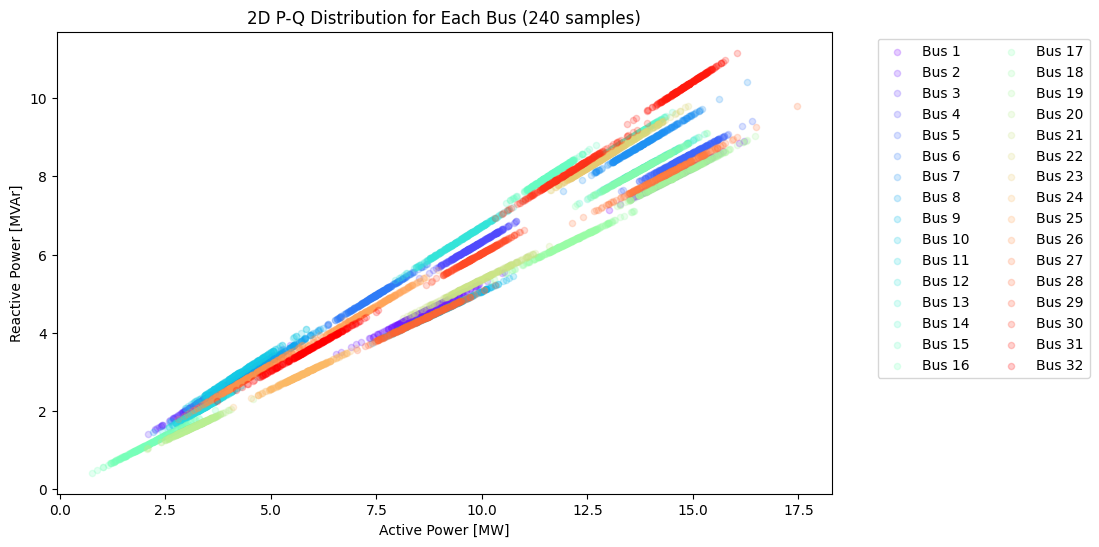

In [4]:
import matplotlib.pyplot as plt

########################################
# Example: High-Dimensional Gaussian Loads
########################################
n_buses = len(net.bus)-1  # number of buses in the network except slack bus
mean_load = np.random.uniform(2, 15, size=n_buses)  # example bus load means in kW
cov_load = np.diag(np.random.uniform(0.1, 0.5, size=n_buses))  # diagonal covariance

# Generate N random samples from this distribution (240 for example)
N = 240
active_power = np.random.multivariate_normal(mean_load, cov_load, size=N)
active_power = np.abs(active_power)  # ensure positivity

# Simple approach for reactive power (Q ~ power_factor * P)
power_factor = np.random.uniform(0.5, 0.7, size=n_buses)
reactive_power = active_power * power_factor

########################################
# 2D P-Q DISTRIBUTION PLOT (240 SAMPLES PER BUS)
########################################
plt.figure(figsize=(10, 6))

# Use a colormap that can produce distinct colors for each bus
colors = plt.cm.rainbow(np.linspace(0, 1, n_buses))

for i in range(n_buses):
    plt.scatter(
        active_power[:, i],
        reactive_power[:, i],
        color=colors[i],
        alpha=0.2,
        s=20,
        label=f"Bus {i+1}"
    )

plt.title("2D P-Q Distribution for Each Bus (240 samples)")
plt.xlabel("Active Power [MW]")
plt.ylabel("Reactive Power [MVAr]")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()


## Explanation of the Conditional GMM Fitting and Visualization Code

Below is a section-by-section explanation of the code snippet, which demonstrates how to:

1. **Fit a Gaussian Mixture Model (GMM)** on bus-level loads plus the overall mean load.
2. **Sample loads conditionally** upon a specified mean load value.
3. **Visualize** both the original distribution of mean loads and a comparison of bus-level data via boxplots.

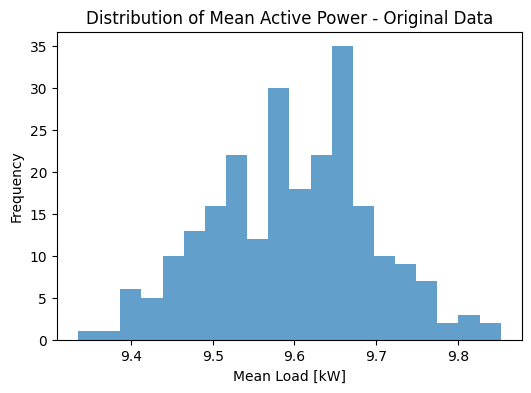

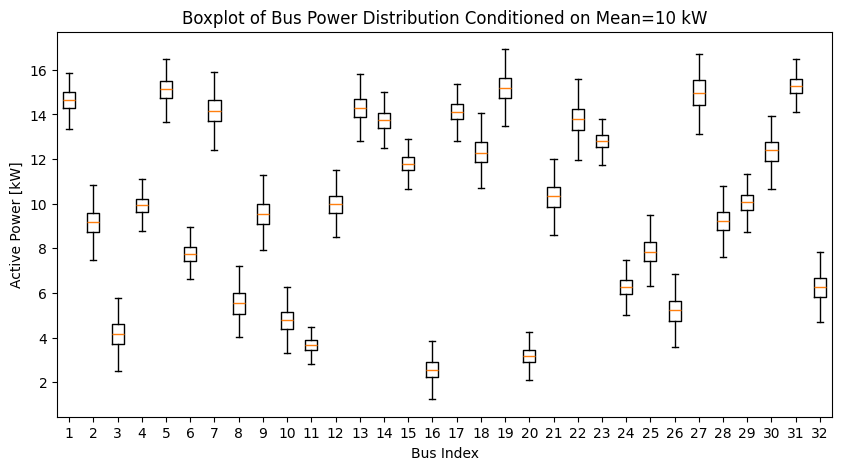

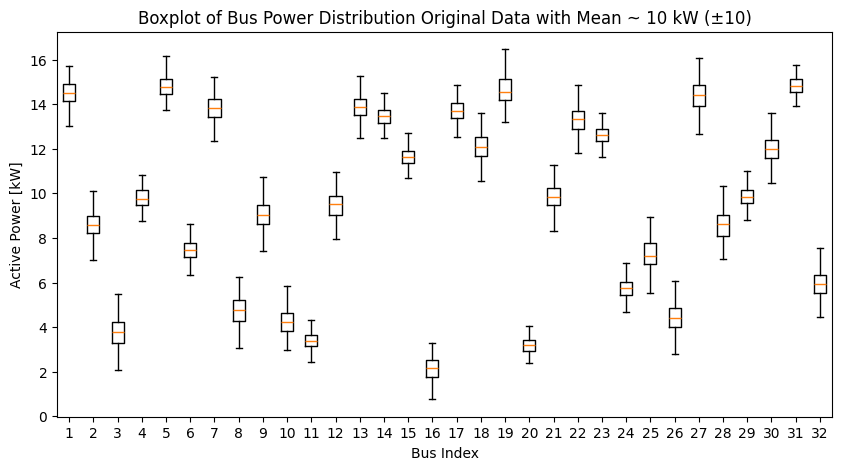

In [5]:

##########################
# USING A GAUSSIAN MIXTURE TO FIT THE LOAD CONDITION
#     ON TOTAL DAILY CONSUMPTION
##########################
# Suppose we treat "total consumption per day" as the sum across all buses.
# We'll fit a GMM on the daily sums from these samples.

# Assume you have the following data:
#   active_power: shape (N, n_buses), i.e. 240 x 33
# Each row is one "sample" (time instance); each column is a bus.

########################################
#  Prepare Data: Active Power + Mean
########################################
N, n_buses = active_power.shape
mean_active_power = active_power.mean(axis=1)

# Stack it as the last column → shape: (N, n_buses + 1)
X = np.hstack([active_power, mean_active_power.reshape(-1, 1)])

########################################
# Fit a GMM on the (n_buses + 1)-dimensional data
########################################
n_components = 2  # number of mixture components (example)
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)

########################################
# Define a function to sample from p(P | mean_load = M)
########################################
def sample_from_conditional_gmm(gmm, mean_value, n_samples=1):
    """
    Samples from the conditional distribution p(P_1, ..., P_n | mean_load = mean_value)
    given a fitted GMM in (n_buses + 1)-dimensional space.
    """
    d1 = gmm.means_.shape[1] - 1   # e.g. number of buses
    samples = np.zeros((n_samples, d1))

    # Arrays to store conditional parameters of each mixture component
    conditional_means = []
    conditional_covs = []
    mixture_weights = []

    for k in range(gmm.n_components):
        mu_k = gmm.means_[k]         # shape: (d1 + 1,)
        Sigma_k = gmm.covariances_[k]  # shape: (d1 + 1, d1 + 1)
        pi_k = gmm.weights_[k]

        # Partition mean vector
        mu_x1 = mu_k[:d1]           # shape: (d1,)
        mu_x2 = mu_k[d1:]           # shape: (1,)

        # Partition covariance
        Sigma_x1x1 = Sigma_k[:d1, :d1]    # (d1, d1)
        Sigma_x2x2 = Sigma_k[d1:, d1:]    # (1, 1)
        Sigma_x1x2 = Sigma_k[:d1, d1:]    # (d1, 1)
        Sigma_x2x1 = Sigma_k[d1:, :d1]    # (1, d1)

        sigma_x2x2 = Sigma_x2x2[0, 0]  # univariate

        # Conditional mean
        cond_mean = mu_x1 + (Sigma_x1x2[:, 0] / sigma_x2x2) * (mean_value - mu_x2[0])
        # Make sure cond_mean is 1D: shape (d1,)
        cond_mean = np.array(cond_mean, ndmin=1)

        # Conditional covariance
        #   Σ_x1|x2 = Σ_x1x1 - Σ_x1x2 Σ_x2x2^-1 Σ_x2x1
        # Note Sigma_x1x2 is (d1, 1), Sigma_x2x1 is (1, d1).
        cond_cov = Sigma_x1x1 - (Sigma_x1x2 @ Sigma_x2x1) / sigma_x2x2
        # Ensure shape is (d1, d1)
        cond_cov = np.atleast_2d(cond_cov)

        # Probability of X2 = mean_value in component k
        from math import sqrt, pi, exp
        def univariate_pdf(x, m, var):
            return 1 / np.sqrt(2 * pi * var) * np.exp(-0.5 * ((x - m) ** 2 / var))

        p_x2_given_k = univariate_pdf(mean_value, mu_x2[0], sigma_x2x2)
        mixture_weights.append(pi_k * p_x2_given_k)

        conditional_means.append(cond_mean)
        conditional_covs.append(cond_cov)

    # Normalize mixture weights robustly (avoid NaN/zero-sum edge cases)
    mixture_weights = np.array(mixture_weights, dtype=float)
    wsum = np.nansum(mixture_weights)
    if (not np.isfinite(wsum)) or (wsum <= 0):
        mixture_weights = np.ones(gmm.n_components, dtype=float) / gmm.n_components
    else:
        mixture_weights = np.nan_to_num(mixture_weights, nan=0.0, posinf=0.0, neginf=0.0)
        mixture_weights /= mixture_weights.sum()

    # Sample from the conditional mixture distribution
    for i in range(n_samples):
        k_choice = np.random.choice(np.arange(gmm.n_components), p=mixture_weights)
        mean_k = conditional_means[k_choice]  # shape (d1,)
        cov_k = conditional_covs[k_choice]    # shape (d1, d1)

        # Draw a sample from the chosen (multivariate) normal
        samples[i, :] = np.random.multivariate_normal(mean_k, cov_k)

    return samples

########################################
# Plot the Distribution of mean_active_power (Original Data)
########################################
mean_active_power = active_power.mean(axis=1)
plt.figure(figsize=(6, 4))
plt.hist(mean_active_power, bins=20, alpha=0.7)
plt.title("Distribution of Mean Active Power - Original Data")
plt.xlabel("Mean Load [kW]")
plt.ylabel("Frequency")
plt.show()

########################################
# Conditional Samples from the GMM at mean_active_power
########################################
# Let's draw a larger set of conditional samples to visualize a distribution
num_conditional_samples_large = 500  # pick a larger number for better stats
sampled_target = 10
conditional_samples_large = sample_from_conditional_gmm(
    gmm,
    mean_value=sampled_target,
    n_samples=num_conditional_samples_large
)
conditional_samples_large = np.abs(conditional_samples_large)

# Boxplot of the bus-level power across the conditional samples
plt.figure(figsize=(10, 5))
plt.boxplot(conditional_samples_large, showfliers=False)
plt.title(f"Boxplot of Bus Power Distribution Conditioned on Mean={sampled_target} kW")
plt.xlabel("Bus Index")
plt.ylabel("Active Power [kW]")
plt.show()

########################################
# Plot Power Distribution of Original Data with Mean ~ 0.10
########################################
# Filter original dataset
tolerance = 10
mask = (mean_active_power >= sampled_target - tolerance) & (mean_active_power <= sampled_target + tolerance)
similar_data = active_power[mask]  # shape = (M, n_buses), M depends on how many rows match

# If we have at least one row matching:
if len(similar_data) > 0:
    plt.figure(figsize=(10, 5))
    plt.boxplot(similar_data, showfliers=False)
    plt.title(f"Boxplot of Bus Power Distribution Original Data with Mean ~ {sampled_target} kW (±{tolerance})")
    plt.xlabel("Bus Index")
    plt.ylabel("Active Power [kW]")
    plt.show()
else:
    print(f"No original samples found with mean load in [{sampled_target - tolerance}, {sampled_target + tolerance}].")


**The following script demonstrates how to:**
1. Generate synthetic load scenarios for an IEEE 33-bus network using a trained Gaussian Mixture Model (GMM).
2. Sample multiple scenarios corresponding to different average load levels (lower and higher).
3. Run a DC power flow on each scenario with pandapower’s IEEE 33-bus case.
4. Extract the bus voltage magnitudes in kV and plot their distributions for each scenario.



 **Task1: Completing the code of sampling load data from GMM**:
   - *You have to write the code to call `sample_from_conditional_gmm(...)` twice, once for the lower mean load and once for the higher mean load.*
   - This function returns synthetic load values (in MW) for each bus in each scenario.
   - We take the absolute value to ensure non-negative loads.



In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- ASSUMPTION: You already have a fitted GMM (gmm)

##########################
# CHOOSE SCENARIOS
##########################
# Here we still assume per-bus load values (from the GMM) in MW.
# Even though DC load flow ignores reactive power,
# the load levels must be within a realistic range.
lower_mean_value = 6  # MW per bus
higher_mean_value = 10 # MW per bus
num_samples = 200      # number of scenarios per mean load


##########################
# SAMPLE LOADS FOR LOWER & HIGHER MEAN
# TASK1: Completing the code of sampling load data from GMM:
##########################
# --------------------------------
# PLEASE write your code here for T1
loads_lower = sample_from_conditional_gmm(
    gmm,
    mean_value=lower_mean_value,
    n_samples=num_samples,
)
loads_higher = sample_from_conditional_gmm(
    gmm,
    mean_value=higher_mean_value,
    n_samples=num_samples,
)

# Ensure non-negative loads (and use a minimum value to avoid zero load issues)
loads_lower = np.abs(loads_lower)
loads_higher = np.abs(loads_higher)
print('Mean of lower loads: ', loads_lower.mean())
print('Mean of higher loads: ', loads_higher.mean())
# --------------------------------


Mean of lower loads:  6.474960363877515
Mean of higher loads:  9.9999421928866



 **Task2: Completing the voltage computation function**:
   - Develop a helper function `run_dc_scenarios_and_get_angles_and_voltages(...)`. You need to complte the part of the function.
   - For each scenario, we:
      - a) A fresh pandapower 33-bus network (IEEE 33-bus) is created.
     - b) Remove any pre-existing loads.
     - c) Add new loads for all buses from our synthetic load scenario.
     - d) *You have to write the code to run a power flow.*



In [7]:

##########################
# FUNCTION: RUN DC POWER FLOW FOR MULTIPLE SCENARIOS
##########################
def run_dc_scenarios_and_get_angles_and_voltages(load_matrix):
    """
    Returns both bus angles (in degrees) and bus voltages (in kV) for each scenario.
    """
    num_scenarios, _ = load_matrix.shape
    voltage_results = np.zeros((num_scenarios, 33))
    power_factor = 0.3

    for i in range(num_scenarios):
        # for node_idx in input_data_pgm['sym_load']['node']:
        input_data_pgm['sym_load']['p_specified'][:32] = load_matrix[i, :32] * 1000  # 1000 is for correct the unit
        input_data_pgm['sym_load']['q_specified'] = input_data_pgm['sym_load']['p_specified'] * power_factor

        # Create a network of power grid model
        newpgm = PowerGridModel(input_data=input_data_pgm, system_frequency=50.0)

        ##########################
        # TASK2: Completing the voltage computation function:
        ##########################
        # --------------------------------
        # PLEASE write your code here for T2
        newoutput = newpgm.calculate_power_flow(max_iterations=100)

        voltage_results[i, :] = newoutput['node']['u_pu']
        # --------------------------------

    return voltage_results


 **Task3: Make use of the function you have developed to get the voltage scenarios**:
   - *Write the code to get all voltage magnitudes by runing the function `run_dc_scenarios_and_get_angles_and_voltages`.*
   - The boxplots of these bus voltages are created to visualize how the voltage distribution changes across scenarios and load levels.

Mean voltage of smaller condition (pu):  0.99751485924942
Mean voltage of larger condition (pu):  0.9960563667401656


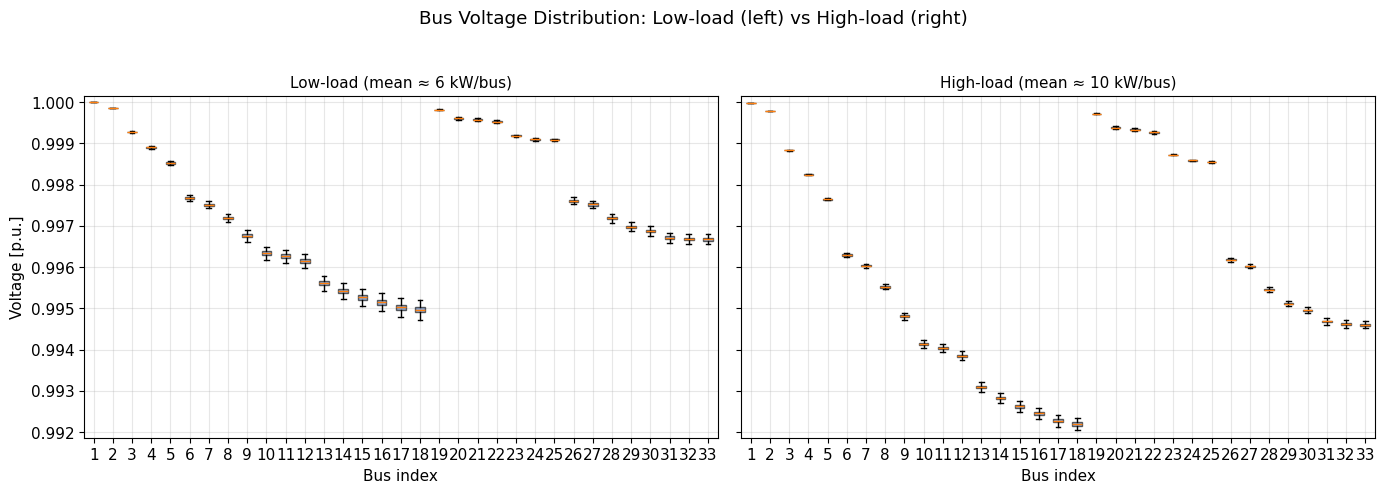

In [8]:

#########################
# RUN AC POWER FLOW FOR LOWER & HIGHER LOADS
# TASK3: Make use of the function you have developed to get the voltage scenarios:
##########################
# --------------------------------
# PLEASE write your code here for T3
voltages_lower = run_dc_scenarios_and_get_angles_and_voltages(loads_lower)
voltages_higher = run_dc_scenarios_and_get_angles_and_voltages(loads_higher)

print('Mean voltage of smaller condition (pu): ', voltages_lower.mean())
print('Mean voltage of larger condition (pu): ', voltages_higher.mean())
# --------------------------------

##########################
# PLOT VOLTAGE DISTRIBUTIONS
# Figure 1 (report-ready): Low-load vs High-load side-by-side
##########################

# Shared y-limits across both scenarios for fair comparison
v_all = np.concatenate([voltages_lower.ravel(), voltages_higher.ravel()])
ymin = float(v_all.min())
ymax = float(v_all.max())
margin = 0.02 * (ymax - ymin) if ymax > ymin else 0.01

ylim = (ymin - margin, ymax + margin)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

common_kwargs = dict(showfliers=False, patch_artist=True)
box_color = '#4C72B0'

bp0 = axes[0].boxplot(voltages_lower, **common_kwargs)
for patch in bp0['boxes']:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.6)

axes[0].axhline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f"Low-load (mean ≈ {lower_mean_value} kW/bus)")
axes[0].set_xlabel('Bus index')
axes[0].set_ylabel('Voltage [p.u.]')
axes[0].set_ylim(*ylim)
axes[0].grid(True, alpha=0.3)

bp1 = axes[1].boxplot(voltages_higher, **common_kwargs)
for patch in bp1['boxes']:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.6)

axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1)
axes[1].set_title(f"High-load (mean ≈ {higher_mean_value} kW/bus)")
axes[1].set_xlabel('Bus index')
axes[1].set_ylim(*ylim)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Bus Voltage Distribution: Low-load (left) vs High-load (right)')
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig('fig1_voltage_boxplots_low_vs_high.png', dpi=150, bbox_inches='tight')
plt.show()


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


Loading sanity check [%] -> low: min=0.000, max=5.523; high: min=0.000, max=8.378


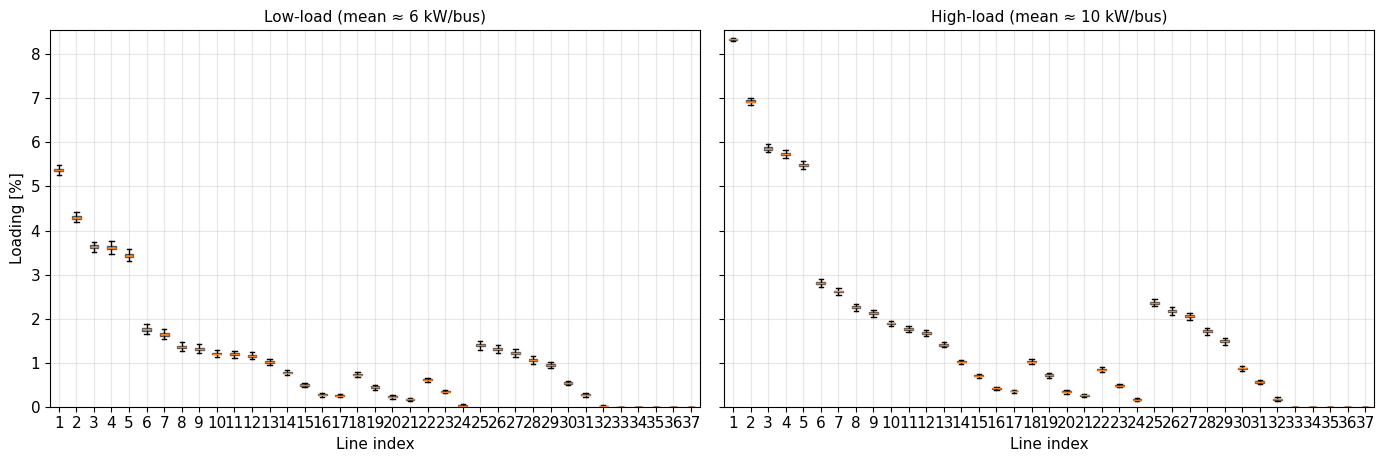

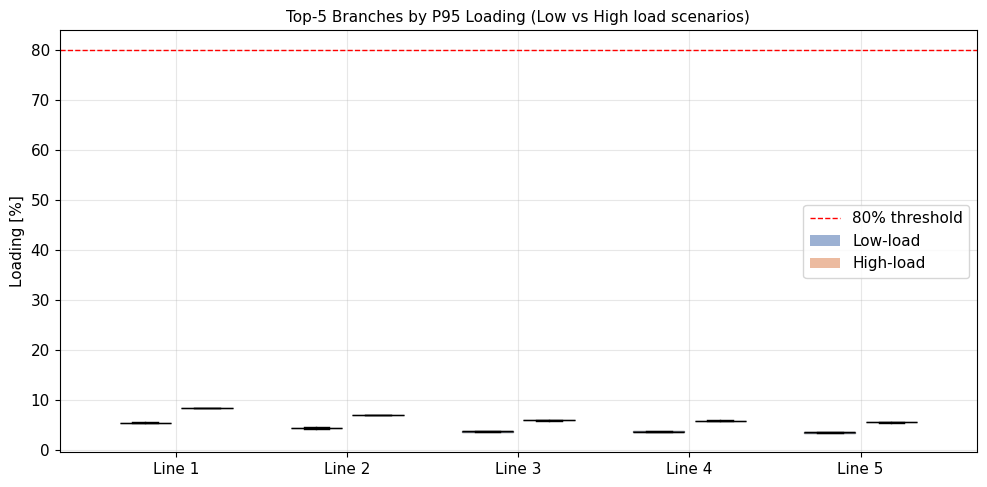


=== Low-load scenarios ===
Top-10 branches by P95 loading [%] (descending):
  Line  1: P95=  5.47%
  Line  2: P95=  4.39%
  Line  3: P95=  3.72%
  Line  4: P95=  3.70%
  Line  5: P95=  3.53%
  Line  6: P95=  1.85%
  Line  7: P95=  1.73%
  Line 25: P95=  1.46%
  Line  8: P95=  1.43%
  Line  9: P95=  1.38%

P(loading > 80%) per branch:
  Line  1: 0.000
  Line  2: 0.000
  Line  3: 0.000
  Line  4: 0.000
  Line  5: 0.000
  Line  6: 0.000
  Line  7: 0.000
  Line  8: 0.000
  Line  9: 0.000
  Line 10: 0.000
  Line 11: 0.000
  Line 12: 0.000
  Line 13: 0.000
  Line 14: 0.000
  Line 15: 0.000
  Line 16: 0.000
  Line 17: 0.000
  Line 18: 0.000
  Line 19: 0.000
  Line 20: 0.000
  Line 21: 0.000
  Line 22: 0.000
  Line 23: 0.000
  Line 24: 0.000
  Line 25: 0.000
  Line 26: 0.000
  Line 27: 0.000
  Line 28: 0.000
  Line 29: 0.000
  Line 30: 0.000
  Line 31: 0.000
  Line 32: 0.000
  Line 33: 0.000
  Line 34: 0.000
  Line 35: 0.000
  Line 36: 0.000
  Line 37: 0.000

Maximum observed loading across a

In [9]:
#########################
# BRANCH LOADING EXTRACTION + PLOTS + STATS (pandapower)
# Added after scenario generation; existing PF/GMM code is unchanged.
#########################

import numpy as np
import matplotlib.pyplot as plt


def run_pp_scenarios_get_voltage_and_loading(load_matrix, net_template):
    """
    Run pandapower AC power flow per scenario and return:
      - bus voltage magnitudes: shape (n_scenarios, n_buses)
      - line loading percentages: shape (n_scenarios, n_lines)
    """
    n_scenarios, _ = load_matrix.shape
    n_buses = net_template.bus.shape[0]
    n_lines = net_template.line.shape[0]

    voltage_results = np.zeros((n_scenarios, n_buses))
    loading_results = np.zeros((n_scenarios, n_lines))

    # Preserve the base reactive-power profile (Q/P ratio) per load.
    base_p_mw = net_template.load.p_mw.to_numpy().copy()
    base_q_mvar = net_template.load.q_mvar.to_numpy().copy()
    q_over_p = np.divide(base_q_mvar, base_p_mw, out=np.zeros_like(base_q_mvar), where=base_p_mw != 0)

    n_loads = min(net_template.load.shape[0], load_matrix.shape[1])

    for i in range(n_scenarios):
        pp.runpp(net_template)
        # Set scenario loads (input matrix in kW -> pandapower expects MW)
        p_scn_mw = np.zeros_like(base_p_mw)
        p_scn_mw[:n_loads] = load_matrix[i, :n_loads] / 1000.0
        q_scn_mvar = p_scn_mw * q_over_p

        net_template.load.loc[:, 'p_mw'] = p_scn_mw
        net_template.load.loc[:, 'q_mvar'] = q_scn_mvar

        # Required extraction after each pp.runpp(net)
        pp.runpp(net_template)
        voltage_results[i, :] = net_template.res_bus['vm_pu'].to_numpy()
        loading_results[i, :] = net_template.res_line['loading_percent'].to_numpy()

    return voltage_results, loading_results


# Use fresh copies so later notebook cells keep the original net behavior.
import copy
net_low = copy.deepcopy(net)
net_high = copy.deepcopy(net)

voltages_pp_lower, loading_lower = run_pp_scenarios_get_voltage_and_loading(loads_lower, net_low)
voltages_pp_higher, loading_higher = run_pp_scenarios_get_voltage_and_loading(loads_higher, net_high)

line_idx = np.arange(1, loading_lower.shape[1] + 1)

#########################
# Figure: line loading distributions, low vs high (side-by-side)
#########################
l_all = np.concatenate([loading_lower.ravel(), loading_higher.ravel()])
ymin_l = float(l_all.min())
ymax_l = float(l_all.max())
margin_l = 0.02 * (ymax_l - ymin_l) if ymax_l > ymin_l else 1.0
ylim_l = (max(0.0, ymin_l - margin_l), ymax_l + margin_l)

print(f"Loading sanity check [%] -> low: min={loading_lower.min():.3f}, max={loading_lower.max():.3f}; "
      f"high: min={loading_higher.min():.3f}, max={loading_higher.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
common_kwargs = dict(showfliers=False, patch_artist=True)
box_color = '#4C72B0'

bp0 = axes[0].boxplot(loading_lower, **common_kwargs)
for patch in bp0['boxes']:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.6)
axes[0].axhline(80.0, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f"Low-load (mean ≈ {lower_mean_value} kW/bus)")
axes[0].set_xlabel('Line index')
axes[0].set_ylabel('Loading [%]')
axes[0].set_ylim(*ylim_l)
axes[0].grid(True, alpha=0.3)

bp1 = axes[1].boxplot(loading_higher, **common_kwargs)
for patch in bp1['boxes']:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.6)
axes[1].axhline(80.0, color='red', linestyle='--', linewidth=1)
axes[1].set_title(f"High-load (mean ≈ {higher_mean_value} kW/bus)")
axes[1].set_xlabel('Line index')
axes[1].set_ylim(*ylim_l)
axes[1].grid(True, alpha=0.3)

# fig.suptitle('Branch Loading Distribution: Low-load (left) vs High-load (right)')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('fig4_branch_loading_boxplots_low_vs_high.png', dpi=150, bbox_inches='tight')
plt.show()

#########################
# Figure: top-5 heaviest-loaded branches (by P95), both scenarios overlaid
#########################
p95_low = np.percentile(loading_lower, 95, axis=0)
p95_high = np.percentile(loading_higher, 95, axis=0)
p95_combined = np.maximum(p95_low, p95_high)

top5_idx = np.argsort(p95_combined)[-5:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(1, len(top5_idx) + 1)

ax.boxplot([loading_lower[:, i] for i in top5_idx], positions=positions - 0.18, widths=0.30,
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.55),
           medianprops=dict(color='black'))
ax.boxplot([loading_higher[:, i] for i in top5_idx], positions=positions + 0.18, widths=0.30,
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='#DD8452', alpha=0.55),
           medianprops=dict(color='black'))

thr = ax.axhline(80.0, color='red', linestyle='--', linewidth=1, label='80% threshold')
ax.set_xticks(positions)
ax.set_xticklabels([f'Line {i+1}' for i in top5_idx])
ax.set_ylabel('Loading [%]')
ax.set_title('Top-5 Branches by P95 Loading (Low vs High load scenarios)')
ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [
    thr,
    Patch(facecolor='#4C72B0', alpha=0.55, label='Low-load'),
    Patch(facecolor='#DD8452', alpha=0.55, label='High-load'),
]
ax.legend(handles=legend_handles, loc='best')

plt.tight_layout()
fig.savefig('fig5_top5_branch_loading_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

#########################
# Required statistics
#########################
def print_loading_stats(name, loading_matrix):
    p95 = np.percentile(loading_matrix, 95, axis=0)
    p_gt_80 = (loading_matrix > 80.0).mean(axis=0)
    max_obs = float(np.max(loading_matrix))

    top10_idx = np.argsort(p95)[-10:][::-1]

    print(f'\n=== {name} ===')
    print('Top-10 branches by P95 loading [%] (descending):')
    for idx in top10_idx:
        print(f'  Line {idx+1:>2}: P95={p95[idx]:6.2f}%')

    print('\nP(loading > 80%) per branch:')
    for idx in range(loading_matrix.shape[1]):
        print(f'  Line {idx+1:>2}: {p_gt_80[idx]:.3f}')

    print(f'\nMaximum observed loading across all scenarios and branches: {max_obs:.2f}%')


print_loading_stats('Low-load scenarios', loading_lower)
print_loading_stats('High-load scenarios', loading_higher)

--- Load magnitude sanity check ---
Base-case total P (pandapower): 3.715 MW  (~3,715,000 W)
Base-case total Q (pandapower): 2.300 MVAr (~2,300,000 var)
Scenario total P (low-load) : mean=207,199 W,  P5=204,237 W,  P95=210,466 W
Scenario total P (high-load): mean=319,998 W, P5=319,940 W, P95=320,061 W
Loading ratio (scenario mean / base): low=0.056, high=0.086


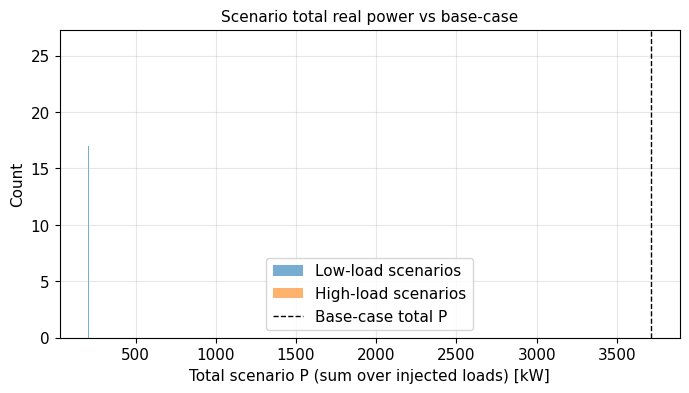


--- System-level voltage risk ---
P(min bus voltage < 0.95) low-load : 0.000
P(min bus voltage < 0.95) high-load: 0.000
E[(0.95 - minV)+] low-load : 0.00000 pu
E[(0.95 - minV)+] high-load: 0.00000 pu

--- Weak-bus indicators ---
Lowest 5th-percentile bus (low-load) : Bus 18 with V5=0.9948 pu
Lowest 5th-percentile bus (high-load): Bus 18 with V5=0.9921 pu

Low-load -- 5 weakest buses:
  Bus 18: median=0.9950, P5=0.9948
  Bus 17: median=0.9950, P5=0.9949
  Bus 16: median=0.9952, P5=0.9950
  Bus 15: median=0.9953, P5=0.9951
  Bus 14: median=0.9954, P5=0.9953

High-load -- 5 weakest buses:
  Bus 18: median=0.9922, P5=0.9921
  Bus 17: median=0.9923, P5=0.9922
  Bus 16: median=0.9925, P5=0.9924
  Bus 15: median=0.9926, P5=0.9925
  Bus 14: median=0.9928, P5=0.9927

--- Soft-risk (for visualization only) ---
Chosen soft threshold v_soft = 0.990 pu
P(minV < v_soft) low-load : 0.000
P(minV < v_soft) high-load: 0.000


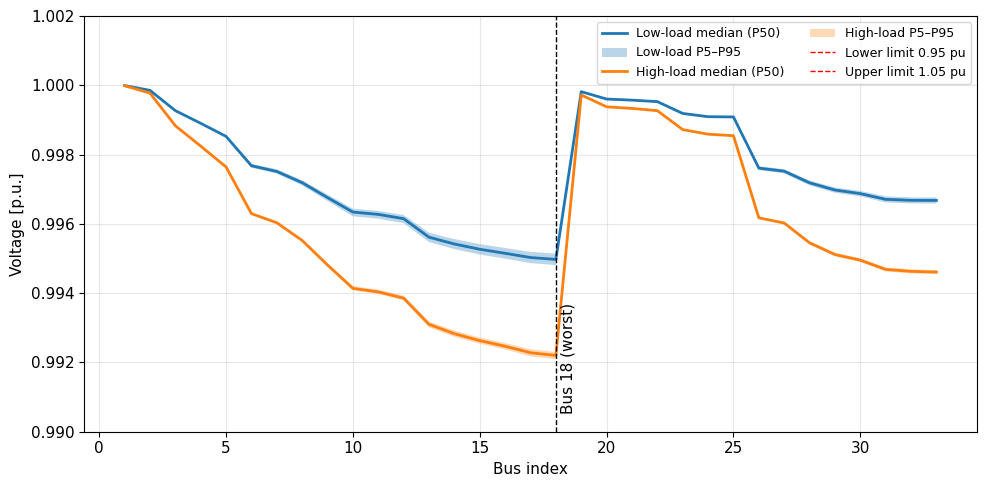

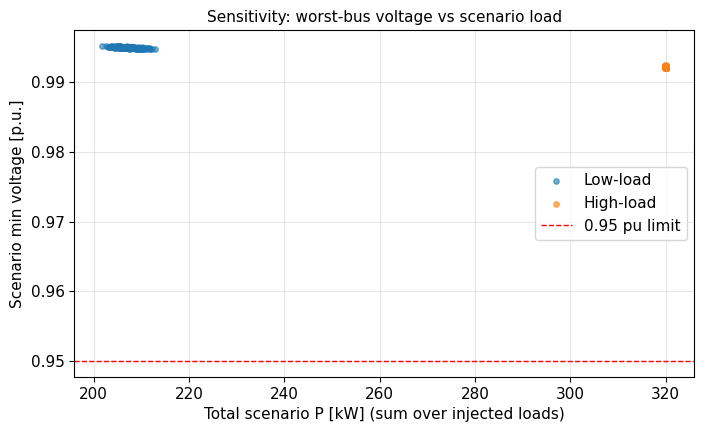

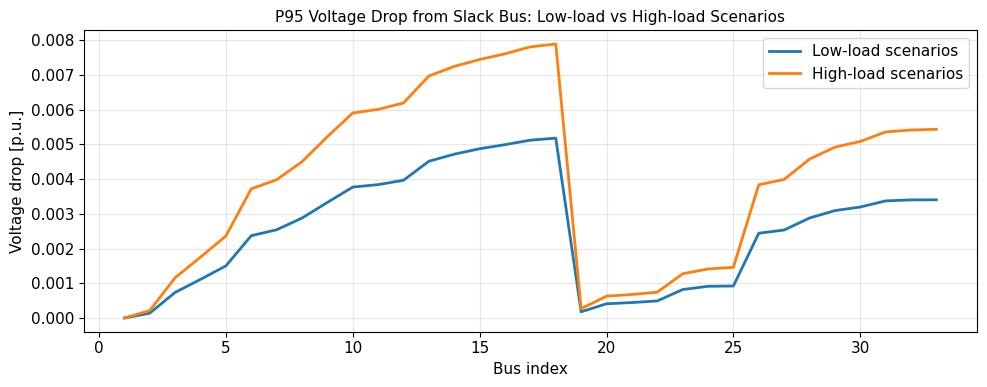

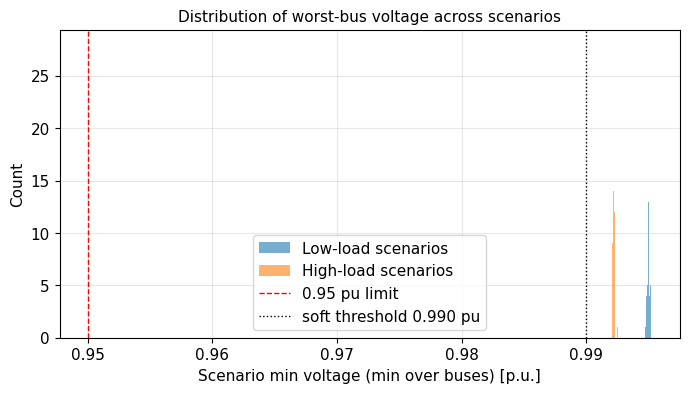

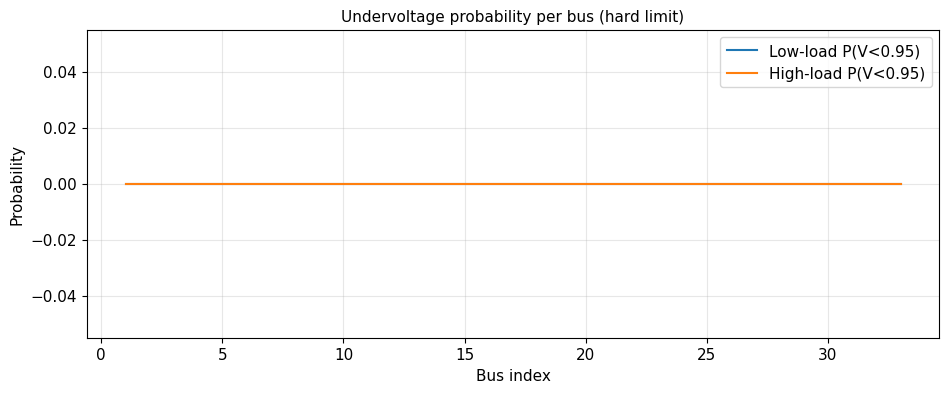

In [10]:
#########################
# EXTRA ANALYSIS (useful for Part III)
# Focus: quantify "how lightly loaded" the scenarios are and show
# a risk-oriented view even when 0.95 pu violations are rare.
#########################
import numpy as np
import matplotlib.pyplot as plt

# --- Sanity checks on shapes
assert voltages_lower.ndim == 2 and voltages_lower.shape[1] == 33
assert voltages_higher.ndim == 2 and voltages_higher.shape[1] == 33

# Voltage limits (adapt if your assignment specifies others)
v_min_limit = 0.95
v_max_limit = 1.05

bus_idx = np.arange(1, 34)  # 1..33

# ---------------------------------------------
# (A) How lightly loaded are the scenarios?
# ---------------------------------------------
# In this notebook, p_specified is in W.
# We inject scenario loads using: load_matrix[kW] * 1000 → W.
# Total injected real power per scenario (W) is therefore approx:
#   sum(loads[:, :32]) * 1000
# (We use :32 to match the assignment helper.)

P_total_low_W = loads_lower[:, :32].sum(axis=1) * 1000
P_total_high_W = loads_higher[:, :32].sum(axis=1) * 1000

# Base-case totals from pandapower (MW) → W
P_base_W = float(net.load.p_mw.sum() * 1e6)
Q_base_var = float(net.load.q_mvar.sum() * 1e6)

print('--- Load magnitude sanity check ---')
print(f'Base-case total P (pandapower): {net.load.p_mw.sum():.3f} MW  (~{P_base_W:,.0f} W)')
print(f'Base-case total Q (pandapower): {net.load.q_mvar.sum():.3f} MVAr (~{Q_base_var:,.0f} var)')
print(f'Scenario total P (low-load) : mean={P_total_low_W.mean():,.0f} W,  P5={np.percentile(P_total_low_W,5):,.0f} W,  P95={np.percentile(P_total_low_W,95):,.0f} W')
print(f'Scenario total P (high-load): mean={P_total_high_W.mean():,.0f} W, P5={np.percentile(P_total_high_W,5):,.0f} W, P95={np.percentile(P_total_high_W,95):,.0f} W')
print(f'Loading ratio (scenario mean / base): low={P_total_low_W.mean()/P_base_W:.3f}, high={P_total_high_W.mean()/P_base_W:.3f}')

plt.figure(figsize=(8, 4))
plt.hist(P_total_low_W/1e3, bins=30, alpha=0.6, label='Low-load scenarios')
plt.hist(P_total_high_W/1e3, bins=30, alpha=0.6, label='High-load scenarios')
plt.axvline(P_base_W/1e3, color='k', linestyle='--', linewidth=1, label='Base-case total P')
plt.xlabel('Total scenario P (sum over injected loads) [kW]')
plt.ylabel('Count')
plt.title('Scenario total real power vs base-case')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---------------------------------------------
# (B) Risk metrics (per-bus and system-level)
# ---------------------------------------------
# Per-bus statistics across scenarios
v5_low = np.percentile(voltages_lower, 5, axis=0)
v50_low = np.percentile(voltages_lower, 50, axis=0)
v95_low = np.percentile(voltages_lower, 95, axis=0)

v5_high = np.percentile(voltages_higher, 5, axis=0)
v50_high = np.percentile(voltages_higher, 50, axis=0)
v95_high = np.percentile(voltages_higher, 95, axis=0)

p_underv_low = (voltages_lower < v_min_limit).mean(axis=0)
p_underv_high = (voltages_higher < v_min_limit).mean(axis=0)

# System-level “tail risk” metric
minV_low = voltages_lower.min(axis=1)   # worst bus per scenario
minV_high = voltages_higher.min(axis=1)

p_any_underv_low = float((minV_low < v_min_limit).mean())
p_any_underv_high = float((minV_high < v_min_limit).mean())

# Expected severity of undervoltage at the worst bus (per scenario)
sev_low = float(np.mean(np.maximum(0.0, v_min_limit - minV_low)))
sev_high = float(np.mean(np.maximum(0.0, v_min_limit - minV_high)))

print('\n--- System-level voltage risk ---')
print(f'P(min bus voltage < {v_min_limit:.2f}) low-load : {p_any_underv_low:.3f}')
print(f'P(min bus voltage < {v_min_limit:.2f}) high-load: {p_any_underv_high:.3f}')
print(f'E[(0.95 - minV)+] low-load : {sev_low:.5f} pu')
print(f'E[(0.95 - minV)+] high-load: {sev_high:.5f} pu')

# Identify weakest buses (by 5th percentile)
weak_low = int(np.argmin(v5_low) + 1)
weak_high = int(np.argmin(v5_high) + 1)
print('\n--- Weak-bus indicators ---')
print(f'Lowest 5th-percentile bus (low-load) : Bus {weak_low} with V5={v5_low[weak_low-1]:.4f} pu')
print(f'Lowest 5th-percentile bus (high-load): Bus {weak_high} with V5={v5_high[weak_high-1]:.4f} pu')

# Exact weak-bus statistics (top-5 weakest buses by 5th percentile)
for scenario_name, voltages in [('Low-load', voltages_lower), ('High-load', voltages_higher)]:
    p5 = np.percentile(voltages, 5, axis=0)
    p50 = np.percentile(voltages, 50, axis=0)
    sorted_idx = np.argsort(p5)[:5]  # 5 weakest buses by P5
    print(f"\n{scenario_name} -- 5 weakest buses:")
    for idx in sorted_idx:
        print(f"  Bus {idx+1}: median={p50[idx]:.4f}, P5={p5[idx]:.4f}")

# If 0.95 pu violations are basically zero, use a tighter threshold to visualize “soft risk”.
# This does NOT change any engineering limit; it just makes the probability plot informative.
v_soft = min(0.99, float(np.min([np.percentile(minV_low, 10), np.percentile(minV_high, 10)])))
if v_soft <= v_min_limit:
    v_soft = 0.99

p_soft_low = float((minV_low < v_soft).mean())
p_soft_high = float((minV_high < v_soft).mean())
print('\n--- Soft-risk (for visualization only) ---')
print(f'Chosen soft threshold v_soft = {v_soft:.3f} pu')
print(f'P(minV < v_soft) low-load : {p_soft_low:.3f}')
print(f'P(minV < v_soft) high-load: {p_soft_high:.3f}')

# ---------------------------------------------
# (C) Plots that remain informative under light loading
# ---------------------------------------------
# Figure 2 (report-ready): Per-bus voltage quantiles overlay
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

plt.figure(figsize=(10, 5))

plt.plot(bus_idx, v50_low, label='Low-load median (P50)', linewidth=2)
plt.fill_between(bus_idx, v5_low, v95_low, alpha=0.30, linewidth=0.0, label='Low-load P5–P95')

plt.plot(bus_idx, v50_high, label='High-load median (P50)', linewidth=2)
plt.fill_between(bus_idx, v5_high, v95_high, alpha=0.30, linewidth=0.0, label='High-load P5–P95')

plt.axhline(v_min_limit, color='red', linestyle='--', linewidth=1, label=f'Lower limit {v_min_limit:.2f} pu')
plt.axhline(v_max_limit, color='red', linestyle='--', linewidth=1, label=f'Upper limit {v_max_limit:.2f} pu')

# Set y-axis limits for report
plt.ylim(0.990, 1.002)

# Mark Bus 18 (worst)
bus_worst = 18
plt.axvline(bus_worst, color='k', linestyle='--', linewidth=1)
plt.text(bus_worst + 0.2, 0.9905, 'Bus 18 (worst)', rotation=90, va='bottom', fontsize=11)

plt.xlabel('Bus index')
plt.ylabel('Voltage [p.u.]')
# plt.title('Per-bus voltage quantiles across scenarios')
plt.grid(True, alpha=0.3)
plt.legend(ncols=2, fontsize=9)

plt.tight_layout()
plt.savefig('fig2_voltage_quantiles_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: worst-bus voltage vs total scenario load (sensitivity)
plt.figure(figsize=(8, 4.5))
plt.scatter(P_total_low_W/1e3, minV_low, s=15, alpha=0.6, label='Low-load')
plt.scatter(P_total_high_W/1e3, minV_high, s=15, alpha=0.6, label='High-load')
plt.axhline(v_min_limit, color='red', linestyle='--', linewidth=1, label=f'{v_min_limit:.2f} pu limit')
plt.xlabel('Total scenario P [kW] (sum over injected loads)')
plt.ylabel('Scenario min voltage [p.u.]')
plt.title('Sensitivity: worst-bus voltage vs scenario load')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Figure 3 (report-ready): P95 voltage drop from slack bus
slack_idx = 0
vdrop_low = voltages_lower[:, slack_idx:slack_idx+1] - voltages_lower
vdrop_high = voltages_higher[:, slack_idx:slack_idx+1] - voltages_higher

vd95_low = np.percentile(vdrop_low, 95, axis=0)
vd95_high = np.percentile(vdrop_high, 95, axis=0)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

plt.figure(figsize=(10, 4))
plt.plot(bus_idx, vd95_low, label='Low-load scenarios', linewidth=2)
plt.plot(bus_idx, vd95_high, label='High-load scenarios', linewidth=2)
plt.xlabel('Bus index')
plt.ylabel('Voltage drop [p.u.]')
plt.title('P95 Voltage Drop from Slack Bus: Low-load vs High-load Scenarios')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('fig3_p95_voltage_drop_from_slack.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: distribution of worst-bus voltage (with both hard + soft thresholds)
plt.figure(figsize=(8, 4.0))
plt.hist(minV_low, bins=30, alpha=0.6, label='Low-load scenarios')
plt.hist(minV_high, bins=30, alpha=0.6, label='High-load scenarios')
plt.axvline(v_min_limit, color='red', linestyle='--', linewidth=1, label=f'{v_min_limit:.2f} pu limit')
plt.axvline(v_soft, color='k', linestyle=':', linewidth=1, label=f'soft threshold {v_soft:.3f} pu')
plt.xlabel('Scenario min voltage (min over buses) [p.u.]')
plt.ylabel('Count')
plt.title('Distribution of worst-bus voltage across scenarios')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot 5: probability of undervoltage per bus (hard threshold)
plt.figure(figsize=(11, 4.0))
plt.plot(bus_idx, p_underv_low, label=f'Low-load P(V<{v_min_limit:.2f})')
plt.plot(bus_idx, p_underv_high, label=f'High-load P(V<{v_min_limit:.2f})')
plt.xlabel('Bus index')
plt.ylabel('Probability')
plt.title('Undervoltage probability per bus (hard limit)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

 **Task 4: Analysis of probabilistic power flow simulations.**

Answer the next questions based on the lecture content and your results:

- What is the added value of a probabilistic power flow simulation analysis,  - - when compared with a deterministic simulation?
- How can this added value be exploited when planning modern power (distribution) systems?
- So far, we have focused on a technical analysis, disregarding any financial aspect. How a probabilistic power flow simulation analysis can also be used when performing a financial analysis in distribution systems planning?